In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import cv2
import os
import tqdm
import numpy as np
from torch.utils.data import DataLoader

In [2]:
torch.cuda.is_available()


True

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
import os
import cv2

train_folder_path_x = "/kaggle/input/cv-project-data/low_resolution"
train_folder_path_y = "/kaggle/input/cv-project-data/high_resolution"
data_tuple = []

class MyDataLoader():
    def make_training_data(self):
        for f in os.listdir(train_folder_path_x):
            image_path_x = os.path.join(train_folder_path_x, f)
            image_path_y = os.path.join(train_folder_path_y, f)

            image_x = cv2.imread(image_path_x)

            image_y = cv2.imread(image_path_y)
            data_tuple.append((image_x,image_y))
                
dataLoader = MyDataLoader()
dataLoader.make_training_data()

In [5]:
from sklearn.model_selection import train_test_split
train_tuple, test_tuple = train_test_split(data_tuple, test_size=0.1, random_state=42)

In [6]:
print(len(train_tuple))
print((train_tuple[20][0]).shape)
print((train_tuple[20][1]).shape)

810
(128, 128, 3)
(512, 512, 3)


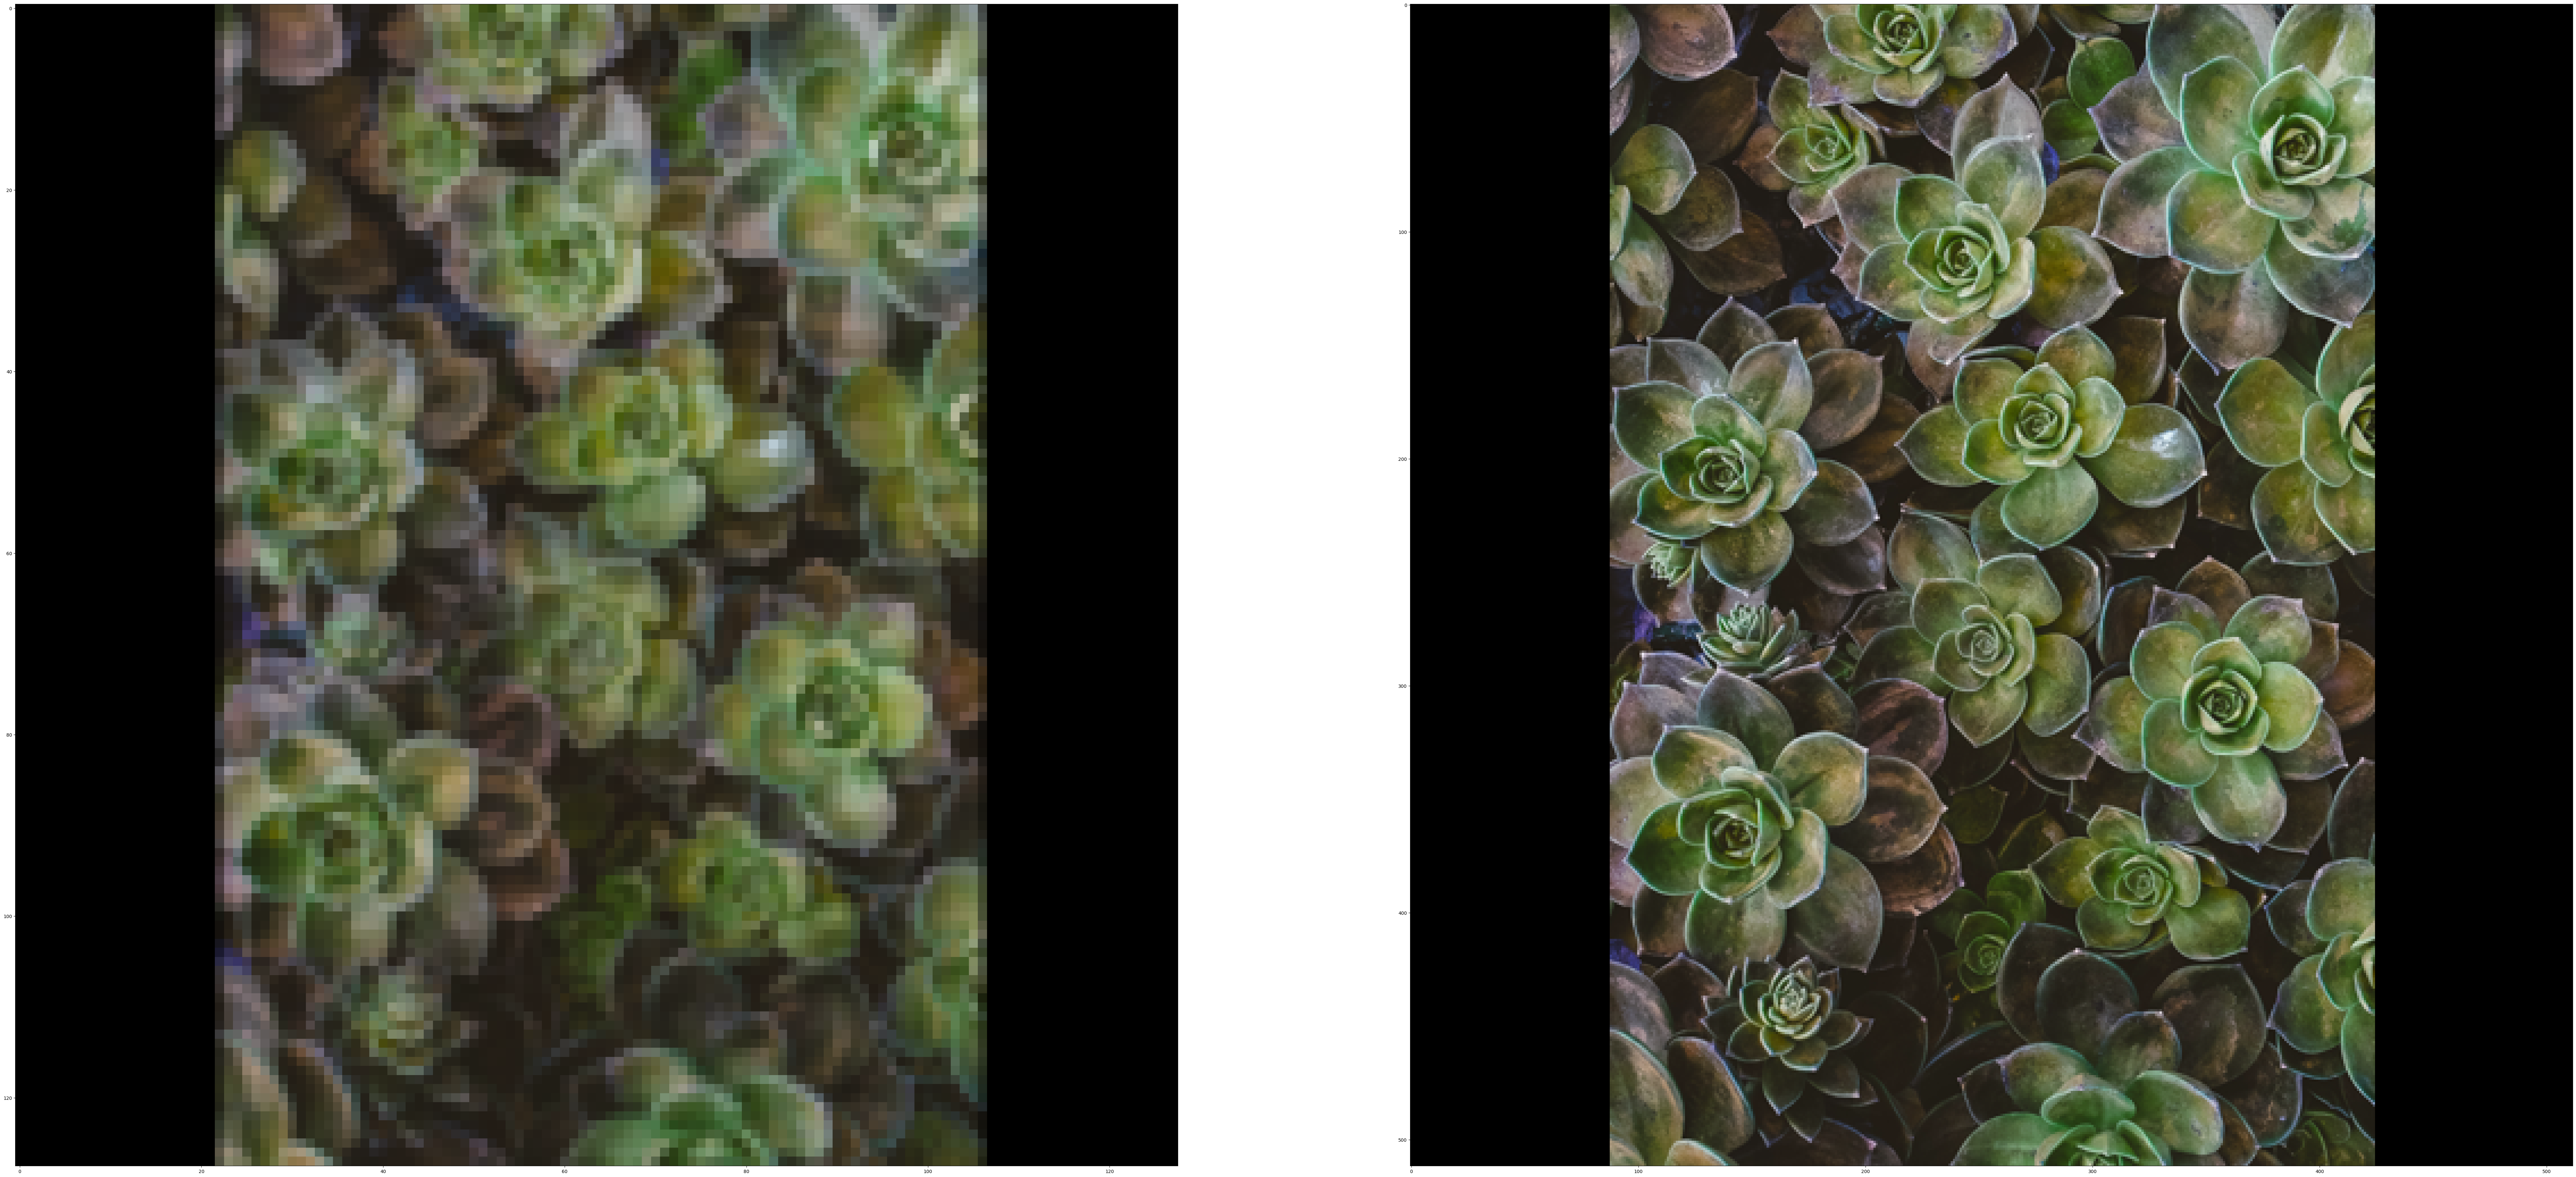

In [7]:
fig = plt.figure(figsize=(100, 100))

fig.add_subplot(1, 2, 1)
plt.imshow(train_tuple[0][0])
fig.add_subplot(1,2, 2)
plt.imshow(train_tuple[0][1])

In [8]:
from torch.utils.data import Dataset
import cv2
import torch

class SRDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        low_res, high_res = self.data[idx]

        # Convert BGR to RGB
        low_res = cv2.cvtColor(low_res, cv2.COLOR_BGR2RGB)
        high_res = cv2.cvtColor(high_res, cv2.COLOR_BGR2RGB)

        # Convert to float and normalize to [0, 1]
        low_res = low_res.astype('float32') / 255.0
        high_res = high_res.astype('float32') / 255.0

        # Convert to PyTorch tensors in [C, H, W] format
        low_res = torch.from_numpy(low_res).permute(2, 0, 1)
        high_res = torch.from_numpy(high_res).permute(2, 0, 1)

        return low_res, high_res

# Create datasets and dataloaders
train_dataset = SRDataset(train_tuple)
test_dataset = SRDataset(test_tuple)

train_dataloader = DataLoader(dataset=train_dataset, batch_size=4, shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=4, shuffle=False)


In [9]:
train_iterator = iter(train_dataloader)
batch = next(train_iterator)
inputs, labels = batch
print(inputs.shape,labels.shape)

torch.Size([4, 3, 128, 128]) torch.Size([4, 3, 512, 512])


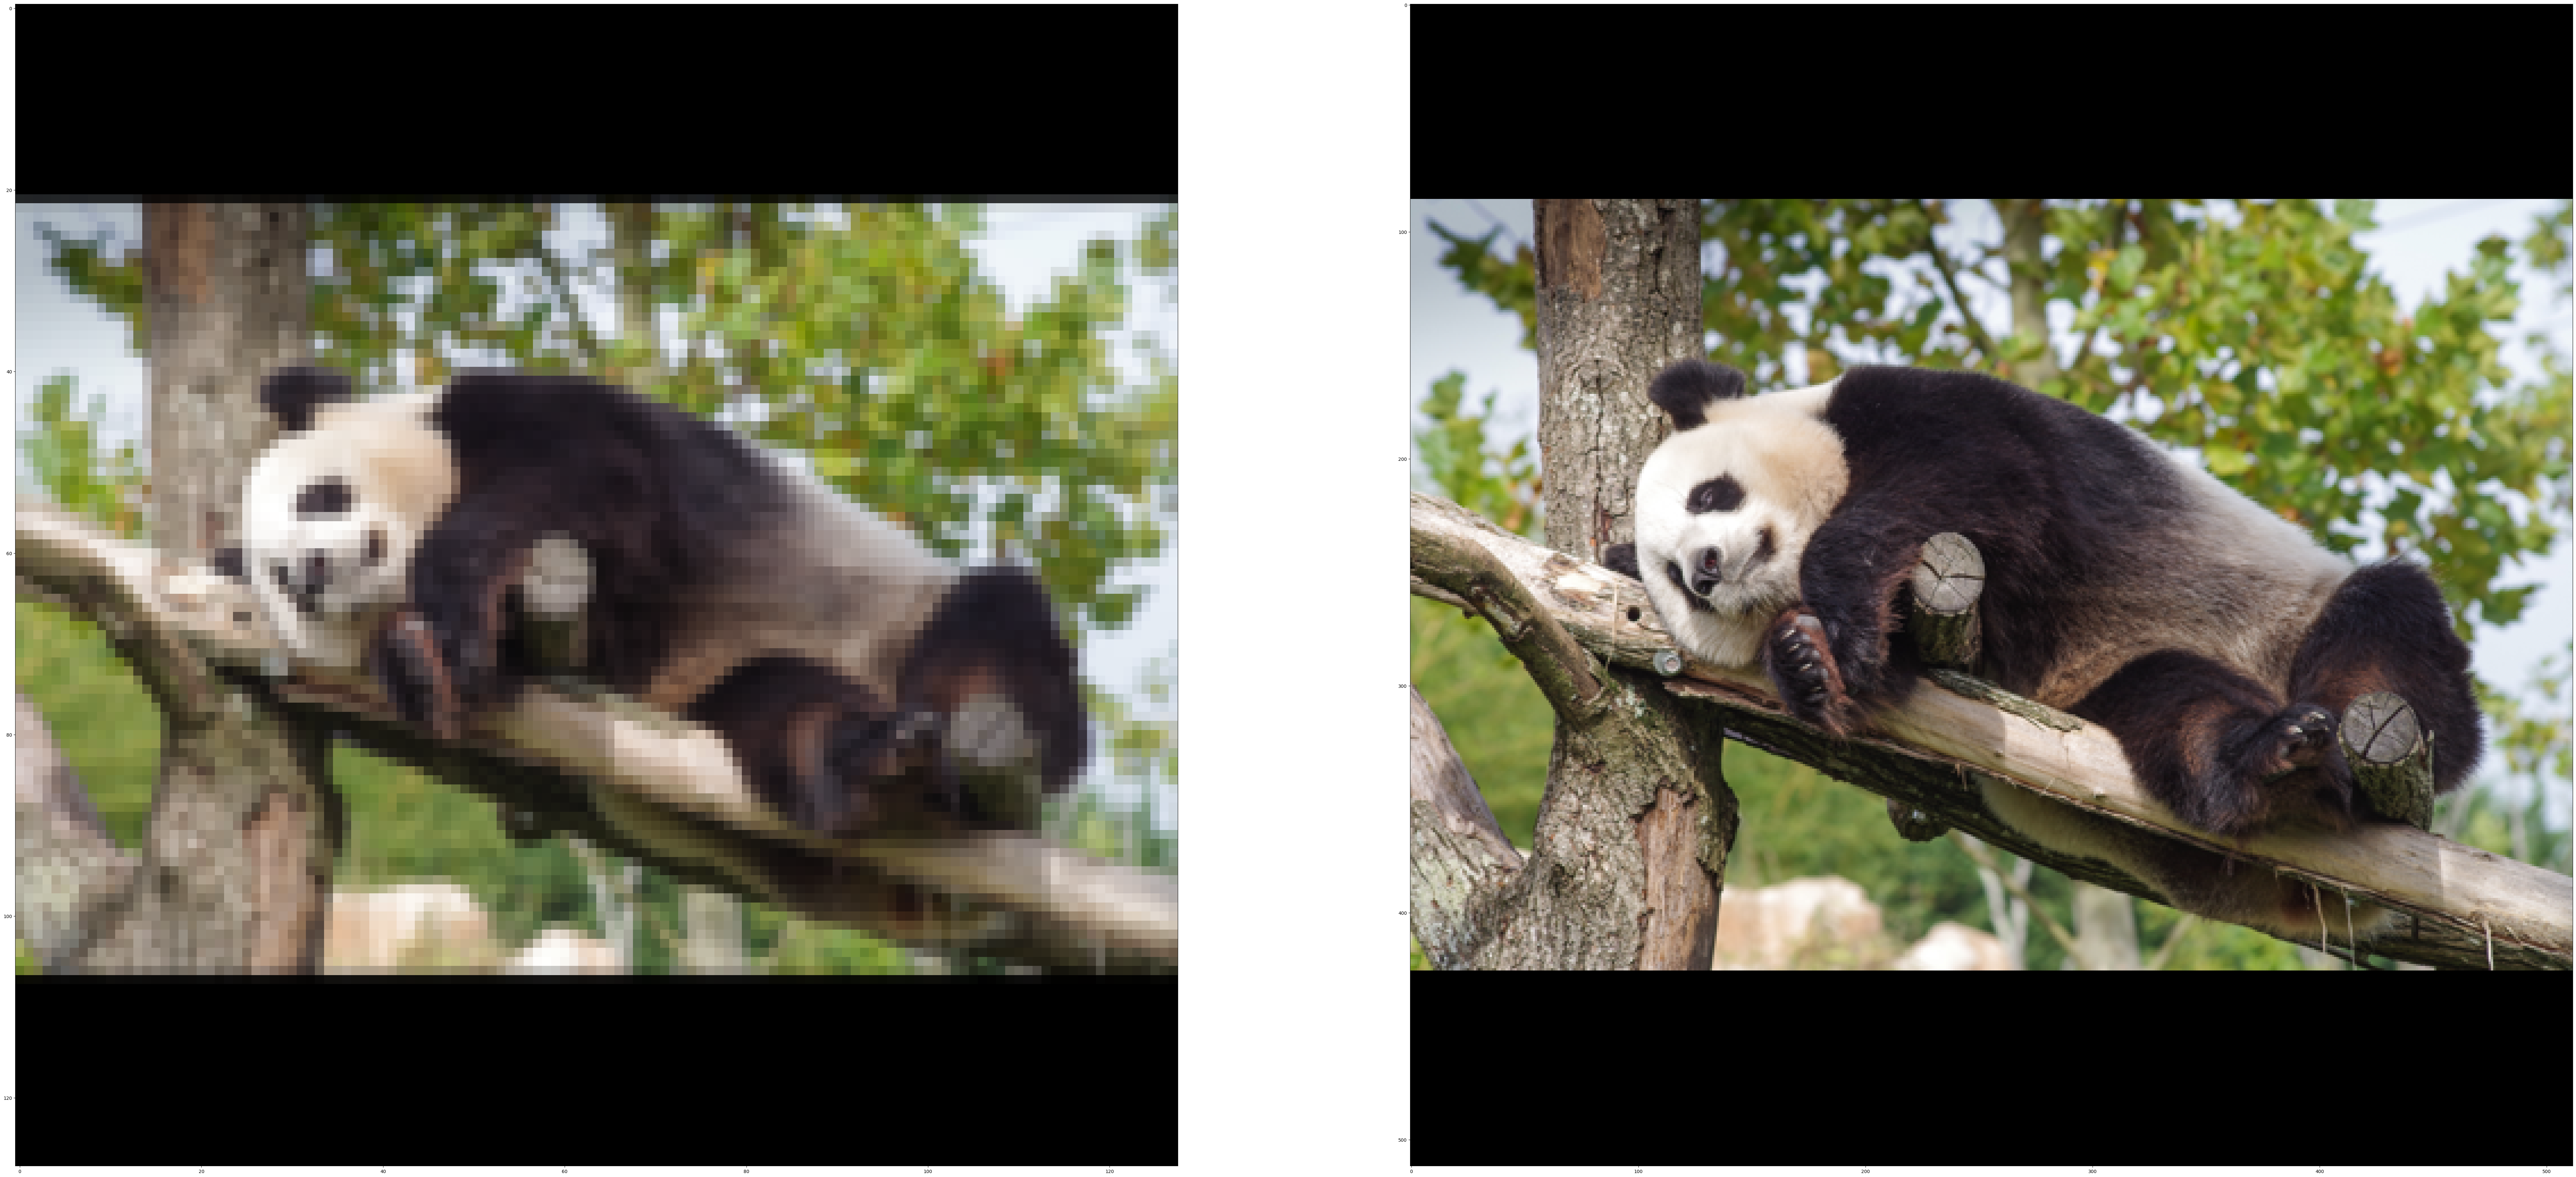

In [10]:
fig = plt.figure(figsize=(100, 100))

fig.add_subplot(1, 2, 1)
plt.imshow(inputs[3].permute(1,2,0).detach().cpu().numpy().astype(np.float32))
fig.add_subplot(1,2, 2)
plt.imshow(labels[3].permute(1,2,0).detach().cpu().numpy().astype(np.float32))

In [11]:
# class VAE(nn.Module):
#   def __init__(self,featureDim=128*32*32, zDim=512):
#     super().__init__()
#     self.enc1 = nn.Conv2d(3, 64, 3, stride=2, padding=1)   # 128 → 64
#     self.enc2 = nn.Conv2d(64, 128, 3, stride=2, padding=1) # 64 → 32
      
#     self.encFC1 = nn.Linear(featureDim, zDim)
#     self.encFC2 = nn.Linear(featureDim, zDim)

#     self.decFC1 = nn.Linear(zDim, featureDim)

#     # DECODER — upsample from 32 → 64 → 128 → 256 → 512
#     self.dec1 = nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1)   # 32 → 64
#     self.dec2 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)    # 64 → 128
#     self.dec3 = nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1)    # 128 → 256
#     self.dec4 = nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1)     # 256 → 512
  
#     self.relu = nn.ReLU()
#     self.sigmoid = nn.Sigmoid()
      
#   def forward(self,x):
#     x = self.relu(self.enc1(x))  # [B, 64, 64, 64]
#     x = self.relu(self.enc2(x))  # [B, 128, 32, 32]

#     # bottleneck
#     x = x.reshape(-1,128*32*32)
#     mu = self.encFC1(x)
#     logVar = self.encFC2(x)

#     # reparameterization
#     std = torch.exp(logVar/2)
#     eps = torch.randn_like(std)
#     z = mu + std * eps

#     x = self.decFC1(z)
#     x = x.reshape(-1,128,32,32)

#     # Decoder
#     x = self.relu(self.dec1(x))  # [B, 64, 64, 64]
#     x = self.relu(self.dec2(x))  # [B, 32, 128, 128]
#     x = self.relu(self.dec3(x))  # [B, 16, 256, 256]
#     x = self.sigmoid(self.dec4(x))  # [B, 3, 512, 512]

#     return x,mu,std

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class VAE(nn.Module):
    def __init__(self, featureDim=128*32*32, zDim=512):
        super().__init__()
        # Encoder
        self.enc1 = nn.Conv2d(3, 64, 3, stride=2, padding=1)   # 128 → 64
        self.enc2 = nn.Conv2d(64, 128, 3, stride=2, padding=1) # 64 → 32

        self.encFC1 = nn.Linear(featureDim, zDim)
        self.encFC2 = nn.Linear(featureDim, zDim)

        self.decFC1 = nn.Linear(zDim, featureDim)

        # Decoder - U-Net style (upsample + skip connections)
        self.dec1 = nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1, output_padding=1)  # 32 → 64
        self.dec2 = nn.ConvTranspose2d(128+64, 64, 3, stride=2, padding=1, output_padding=1)  # 64 → 128
        self.dec3 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)  # 128 → 256
        self.dec4 = nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1)  # 256 → 512

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        e1 = self.relu(self.enc1(x))  # [B, 64, 64, 64]
        e2 = self.relu(self.enc2(e1))  # [B, 128, 32, 32]
        flat = e2.view(e2.size(0), -1)
        mu = self.encFC1(flat)
        logVar = self.encFC2(flat)
        return mu, logVar, e1, e2

    def reparameterize(self, mu, logVar):
        std = torch.exp(0.5 * logVar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, e1):
        x = self.decFC1(z).view(-1, 128, 32, 32)
        d1 = self.relu(self.dec1(x))               # [B, 128, 64, 64]
        d1_cat = torch.cat([d1, e1], dim=1)        # concat skip
        d2 = self.relu(self.dec2(d1_cat))          # [B, 64, 128, 128]
        d3 = self.relu(self.dec3(d2))              # [B, 32, 256, 256]
        d4 = self.sigmoid(self.dec4(d3))           # [B, 3, 512, 512]
        return d4

    def forward(self, x):
        mu, logVar, e1, e2 = self.encode(x)
        z = self.reparameterize(mu, logVar)
        x_recon = self.decode(z, e1)
        return x_recon, mu, logVar

In [13]:
# model = VAE()
# model = nn.DataParallel(model, device_ids=[0, 1])
# model.to(device)

# criterion = nn.MSELoss()
# def vae_loss(recon_x, x, mu, logvar):
#     # Reconstruction loss
#     criterion = nn.MSELoss()
#     recon_loss = criterion(recon_x,x)
#     # KL divergence
#     kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
#     return recon_loss + kl_divergence

# optimizer = torch.optim.Adam(model.parameters(),
#                              lr=0.0001)
# model

In [14]:
# Loss functions
def vae_loss(recon_x, x, mu, logvar, beta=1e-4):
    recon_loss = F.mse_loss(recon_x, x)
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.numel()
    return recon_loss + beta * kl_div

# Optional perceptual loss using pretrained VGG16
class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(pretrained=True).features[:16].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg

    def forward(self, x, y):
        x_feat = self.vgg(x)
        y_feat = self.vgg(y)
        return F.mse_loss(x_feat, y_feat)

# Instantiate model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)
model = nn.DataParallel(model)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
percep_loss_fn = PerceptualLoss().to(device)  # Optional

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 222MB/s]  


In [15]:
# num_epochs = 100
# training_loss = []
# testing_loss = []

# def train():
#     for epoch in range(num_epochs):
#         model.train()
#         train_loss = 0.0

#         for x, y in train_dataloader:
#             x = x.to(device)  # [B, 3, 128, 128]
#             y = y.to(device)  # [B, 3, 512, 512]
#             recon,mu,std = model(x)  # Output: [B, 3, 512, 512]
#             # loss = criterion(recon, y)
#             loss = vae_loss(recon, y,mu,std)

#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#             train_loss += loss.item()

#         avg_train_loss = train_loss / len(train_dataloader)
#         training_loss.append(avg_train_loss)
#         print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}")

#         # Test every 10 epochs
#         if (epoch + 1) % 10 == 0:
#             model.eval()
#             test_loss = 0.0
#             with torch.no_grad():
#                 for x, y in test_dataloader:
#                     x = x.to(device)
#                     y = y.to(device)
#                     recon,mu,std = model(x)
#                     # loss = criterion(recon, y)
#                     loss = vae_loss(recon, y,mu,std)
#                     test_loss += loss.item()

#             avg_test_loss = test_loss / len(test_dataloader)
#             testing_loss.append(avg_test_loss)
#             print(f"→ Test Loss at Epoch {epoch+1}: {avg_test_loss:.4f}")


In [16]:
num_epochs = 1
training_loss = []
testing_loss = []

def train():
    min_testing_loss=10000
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for x, y in train_dataloader:
            x = x.to(device)  # [B, 3, 128, 128]
            y = y.to(device)  # [B, 3, 512, 512]
            recon_x, mu, logvar = model(x)
            loss = vae_loss(recon_x, y, mu, logvar)
            loss += 0.01 * percep_loss_fn(recon_x, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_dataloader)
        training_loss.append(avg_train_loss)
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}")

        # Test every 10 epochs
        if (epoch) % 10 == 0:
            model.eval()
            test_loss = 0.0
            with torch.no_grad():
                for x, y in test_dataloader:
                    x = x.to(device)
                    y = y.to(device)
                    recon_x, mu, logvar = model(x)
                    loss = vae_loss(recon_x, y, mu, logvar)
                    loss += 0.01 * percep_loss_fn(recon_x, y)
                    test_loss += loss.item()

            avg_test_loss = test_loss / len(test_dataloader)
            testing_loss.append(avg_test_loss)
            print(f"→ Test Loss at Epoch {epoch+1}: {avg_test_loss:.4f}")
            if(avg_test_loss<min_testing_loss):
                min_testing_loss = avg_test_loss
                state = {
                    'epoch': num_epochs,
                    'state_dict': model.state_dict(),
                    'optimizer': optimizer.state_dict(),
                }
                filepath = "/kaggle/working/model_vae.pth"
                torch.save(state, filepath)
            


In [17]:
train()

Epoch 1/100, Train Loss: 0.1031
→ Test Loss at Epoch 1: 0.0682
Epoch 2/100, Train Loss: 0.0586
Epoch 3/100, Train Loss: 0.0413
Epoch 4/100, Train Loss: 0.0378
Epoch 5/100, Train Loss: 0.0360
Epoch 6/100, Train Loss: 0.0344
Epoch 7/100, Train Loss: 0.0328
Epoch 8/100, Train Loss: 0.0311
Epoch 9/100, Train Loss: 0.0296
Epoch 10/100, Train Loss: 0.0284
Epoch 11/100, Train Loss: 0.0275
→ Test Loss at Epoch 11: 0.0249
Epoch 12/100, Train Loss: 0.0269
Epoch 13/100, Train Loss: 0.0264
Epoch 14/100, Train Loss: 0.0260
Epoch 15/100, Train Loss: 0.0256
Epoch 16/100, Train Loss: 0.0253
Epoch 17/100, Train Loss: 0.0250
Epoch 18/100, Train Loss: 0.0247
Epoch 19/100, Train Loss: 0.0248
Epoch 20/100, Train Loss: 0.0244
Epoch 21/100, Train Loss: 0.0242
→ Test Loss at Epoch 21: 0.0221
Epoch 22/100, Train Loss: 0.0240
Epoch 23/100, Train Loss: 0.0239
Epoch 24/100, Train Loss: 0.0238
Epoch 25/100, Train Loss: 0.0236
Epoch 26/100, Train Loss: 0.0235
Epoch 27/100, Train Loss: 0.0232
Epoch 28/100, Train Los

KeyboardInterrupt: 

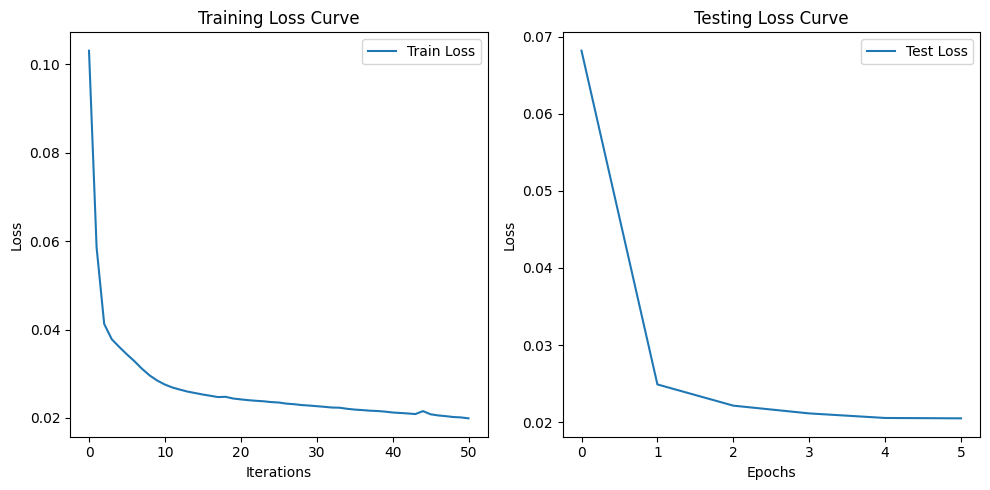

In [18]:
# Plotting
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(len(training_loss)), training_loss, label='Train Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(len(testing_loss)), testing_loss, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Testing Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
def train_result(index):
    x, y = train_tuple[index]

    # Convert BGR to RGB
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    y = cv2.cvtColor(y, cv2.COLOR_BGR2RGB)

    # Convert to float and normalize to [0, 1]
    x = x.astype('float32') / 255.0
    y = y.astype('float32') / 255.0

    # Convert to PyTorch tensors in [C, H, W] format
    x = torch.from_numpy(x).permute(2, 0, 1)
    y = torch.from_numpy(y).permute(2, 0, 1)

    x = x.unsqueeze(dim=0)
    y = y.unsqueeze(dim=0)
    
    model.eval()
    # Train generator
    y_fake,mu,std = model(x)
    print(y_fake.shape)
    fig = plt.figure(figsize=(80, 80))

    fig.add_subplot(1, 3, 1)
    plt.imshow(x[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    fig.add_subplot(1,3, 2)
    plt.imshow(y[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    fig.add_subplot(1, 3, 3)
    print(y_fake[0].permute(1,2,0).cpu().detach().numpy().shape)
    plt.imshow(y_fake[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    model.train()

torch.Size([1, 3, 512, 512])
(512, 512, 3)


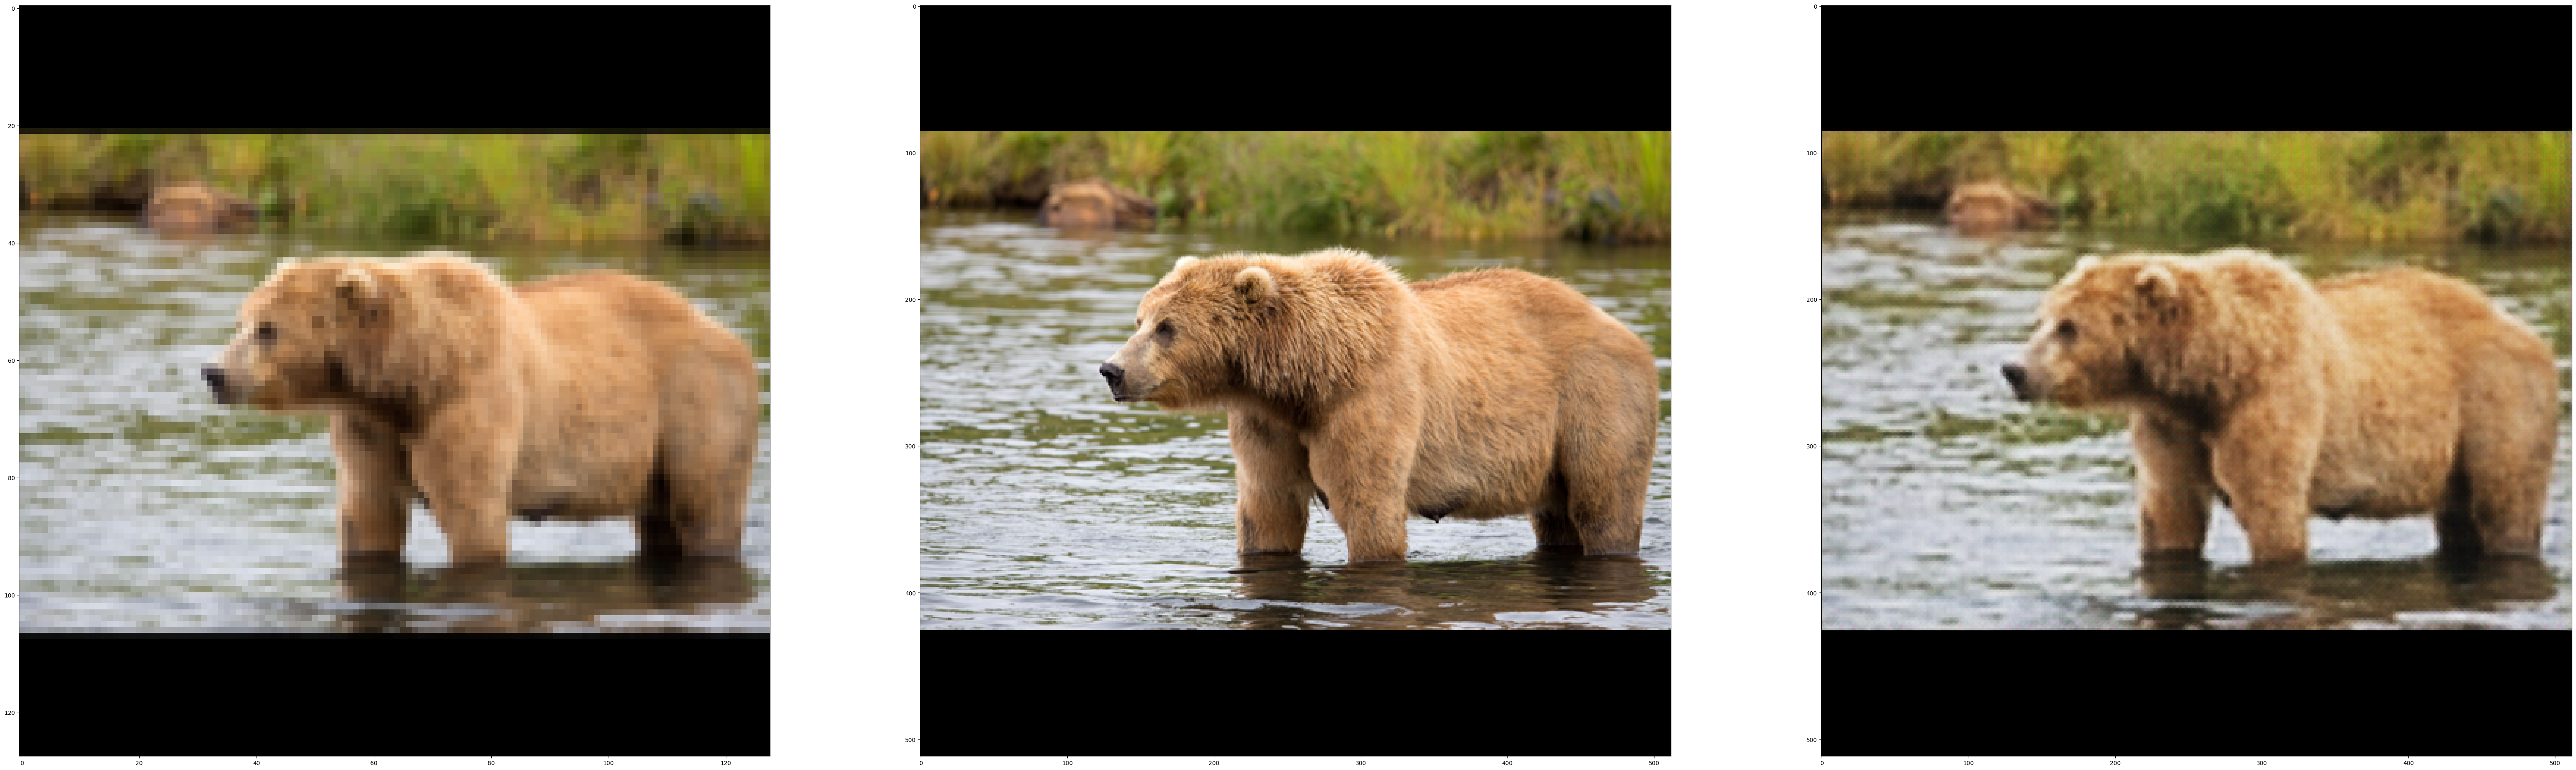

In [20]:
train_result(13)

In [21]:
def test_result(index):
    x, y = test_tuple[index]

    # Convert BGR to RGB
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    y = cv2.cvtColor(y, cv2.COLOR_BGR2RGB)

    # Convert to float and normalize to [0, 1]
    x = x.astype('float32') / 255.0
    y = y.astype('float32') / 255.0

    # Convert to PyTorch tensors in [C, H, W] format
    x = torch.from_numpy(x).permute(2, 0, 1)
    y = torch.from_numpy(y).permute(2, 0, 1)

    x = x.unsqueeze(dim=0)
    y = y.unsqueeze(dim=0)
    
    model.eval()
    # Train generator
    y_fake,mu,std = model(x)
    print(y_fake.shape)
    fig = plt.figure(figsize=(80, 80))

    fig.add_subplot(1, 3, 1)
    plt.imshow(x[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    fig.add_subplot(1,3, 2)
    plt.imshow(y[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    fig.add_subplot(1, 3, 3)
    print(y_fake[0].permute(1,2,0).cpu().detach().numpy().shape)
    plt.imshow(y_fake[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    model.train()

torch.Size([1, 3, 512, 512])
(512, 512, 3)


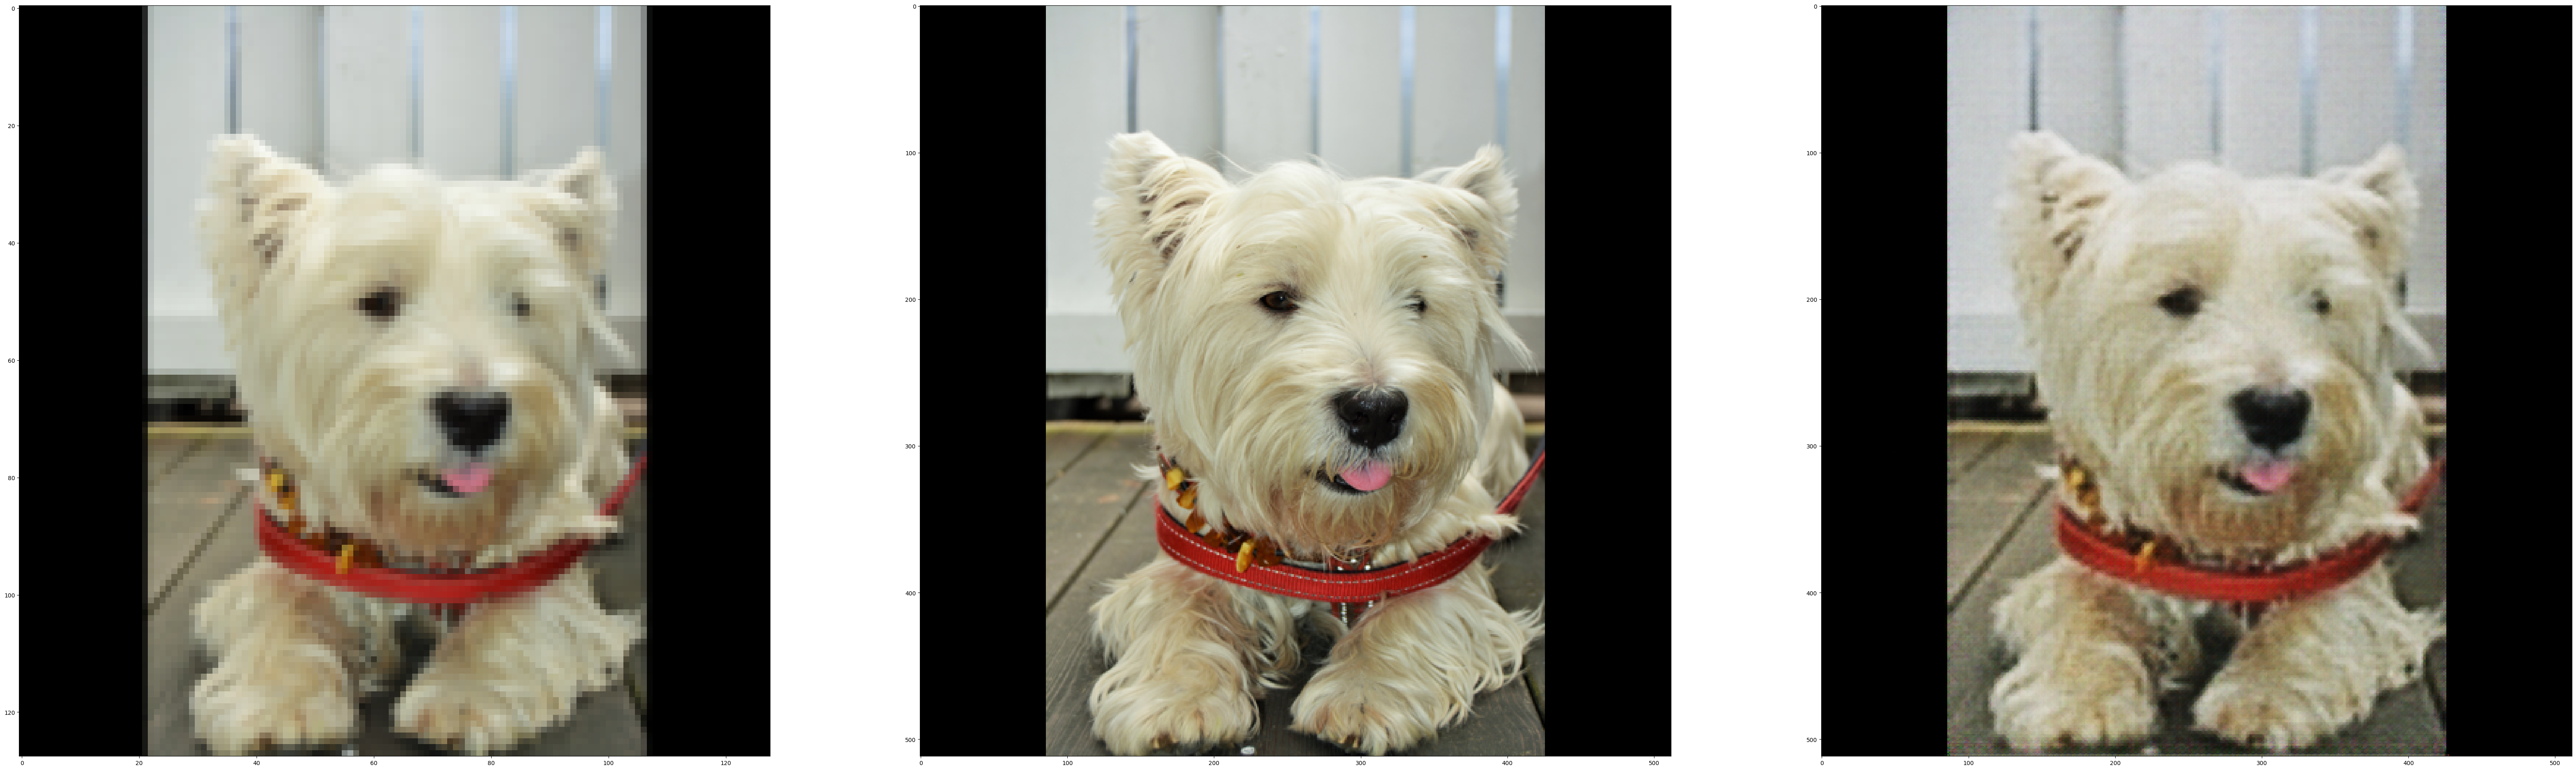

In [22]:
test_result(80)

In [23]:
import torch
import numpy as np
import cv2
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnr_list = []
ssim_list = []

model.eval()
for index in range(len(test_tuple)):
    x, y = test_tuple[index]

    # Convert BGR to RGB
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    y = cv2.cvtColor(y, cv2.COLOR_BGR2RGB)

    # Normalize
    x = x.astype('float32') / 255.0
    y = y.astype('float32') / 255.0

    # Convert to PyTorch tensor [C, H, W]
    x_tensor = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0)
    y_tensor = torch.from_numpy(y).permute(2, 0, 1).unsqueeze(0)

    # Run model
    with torch.no_grad():
        y_fake,mu,std = model(x_tensor)

    # Convert tensors back to NumPy [H, W, C]
    y_np = y_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    y_fake_np = y_fake.squeeze().permute(1, 2, 0).cpu().numpy()

    # Clip to valid range
    y_np = np.clip(y_np, 0, 1)
    y_fake_np = np.clip(y_fake_np, 0, 1)

    # Compute metrics
    psnr_val = psnr(y_np, y_fake_np, data_range=1.0)
    ssim_val = ssim(y_np, y_fake_np, data_range=1.0, channel_axis=2)

    psnr_list.append(psnr_val)
    ssim_list.append(ssim_val)

# Print average PSNR and SSIM
avg_psnr = sum(psnr_list) / len(psnr_list)
avg_ssim = sum(ssim_list) / len(ssim_list)

print(f"Average PSNR: {avg_psnr:.4f}")
print(f"Average SSIM: {avg_ssim:.4f}")

Average PSNR: 24.7031
Average SSIM: 0.7536
